### Import Libraries

In [19]:
import numpy as np
import pickle
from pathlib import Path
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,LSTM,Embedding,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (classification_report,confusion_matrix,accuracy_score,precision_score,recall_score,f1_score)
import matplotlib.pyplot as plt
import seaborn as sns

### project paths

In [4]:
BASE_DIR = Path.cwd().parent.parent
DATA_DIR     = BASE_DIR / "data"
FEATURES_DIR = DATA_DIR / "dl_features"
MODELS_DIR   = FEATURES_DIR

print("BASE_DIR      :", BASE_DIR)
print("FEATURES_DIR  :", FEATURES_DIR)

BASE_DIR      : c:\Users\mereh\nlp-fake-news-detector-transformers
FEATURES_DIR  : c:\Users\mereh\nlp-fake-news-detector-transformers\data\dl_features


### Load preprocessed features

In [5]:
def load_features():
    print("Loading preprocessed features...")

    X_train = np.load(FEATURES_DIR / "X_train_pad.npy")
    X_val   = np.load(FEATURES_DIR / "X_val_pad.npy")
    X_test  = np.load(FEATURES_DIR / "X_test_pad.npy")

    y_train = np.load(FEATURES_DIR / "y_train.npy")
    y_val   = np.load(FEATURES_DIR / "y_val.npy")
    y_test  = np.load(FEATURES_DIR / "y_test.npy")

    with open(FEATURES_DIR / "meta.pkl", "rb") as f:
        meta = pickle.load(f)

    with open(FEATURES_DIR / "tokenizer.pkl", "rb") as f:
        tokenizer = pickle.load(f)

    print(f"  X_train shape : {X_train.shape}")
    print(f"  X_val   shape : {X_val.shape}")
    print(f"  X_test  shape : {X_test.shape}")
    print(f"  max_len       : {meta['max_len']}")
    print(f"  max_words     : {meta['max_words']}")
    print(f"  Vocab size    : {len(tokenizer.word_index)}")

    return X_train, X_val, X_test, y_train, y_val, y_test, meta, tokenizer

In [6]:
X_train, X_val, X_test, y_train, y_val, y_test, meta, tokenizer = load_features()

Loading preprocessed features...
  X_train shape : (963423, 20)
  X_val   shape : (222329, 20)
  X_test  shape : (296438, 20)
  max_len       : 20
  max_words     : 20000
  Vocab size    : 295251


In [7]:
max_words = meta['max_words']
max_len = meta['max_len']

### build LSTM model

In [8]:
model = Sequential([
    Input(shape=(max_len,)),

    Embedding(
        input_dim = max_words,
        output_dim = 128,
    ),
    
    LSTM(64),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dense(1, activation="sigmoid")

])

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,613,633 (9.97 MB)

 Trainable params: 2,613,633 (9.97 MB)

 Non-trainable params: 0 (0.00 B)

### Compile model

In [10]:
model.compile(
    loss = "binary_crossentropy",
    optimizer = Adam(learning_rate=0.001),
    metrics = ["accuracy"]
)

### Early stopping

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

### Train model

In [12]:
history = model.fit(
    X_train, 
    y_train,
    validation_data = (X_val, y_val),
    epochs = 5,
    batch_size = 128,
    callbacks=[early_stop]
)

Epoch 1/5
7527/7527 ━━━━━━━━━━━━━━━━━━━━ 219s 29ms/step - accuracy: 0.7812 - loss: 0.4628 - val_accuracy: 0.7939 - val_loss: 0.4415
Epoch 2/5
7527/7527 ━━━━━━━━━━━━━━━━━━━━ 255s 34ms/step - accuracy: 0.8054 - loss: 0.4221 - val_accuracy: 0.7975 - val_loss: 0.4369
Epoch 3/5
7527/7527 ━━━━━━━━━━━━━━━━━━━━ 227s 30ms/step - accuracy: 0.8183 - loss: 0.3992 - val_accuracy: 0.7964 - val_loss: 0.4392
Epoch 4/5
7527/7527 ━━━━━━━━━━━━━━━━━━━━ 228s 30ms/step - accuracy: 0.8305 - loss: 0.3753 - val_accuracy: 0.7933 - val_loss: 0.4484


### Evaluate model

In [13]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

9264/9264 ━━━━━━━━━━━━━━━━━━━━ 29s 3ms/step - accuracy: 0.7964 - loss: 0.4368
Test Loss: 0.4368
Test Accuracy: 0.7964


### Predict probabilities

In [14]:
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

9264/9264 ━━━━━━━━━━━━━━━━━━━━ 26s 3ms/step


### Plot accuracy & loss

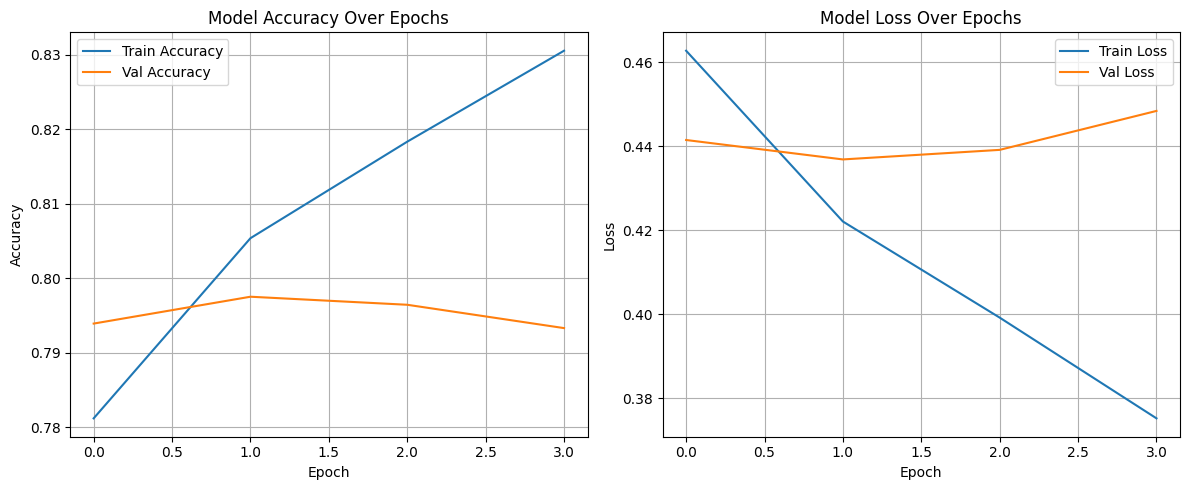

In [16]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### calculate metrics & classification report


In [31]:
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Real", "Fake"]))

Accuracy : 0.7964
Precision: 0.7916
Recall   : 0.7980
F1-Score : 0.7948

Classification Report:
              precision    recall  f1-score   support

        Real       0.80      0.79      0.80    149933
        Fake       0.79      0.80      0.79    146505

    accuracy                           0.80    296438
   macro avg       0.80      0.80      0.80    296438
weighted avg       0.80      0.80      0.80    296438



### Confusion Matrix

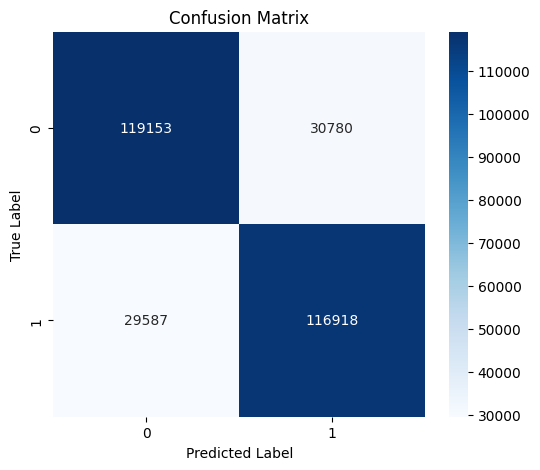

In [34]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()